# Developer Economics & Language Trends (Stack Overflow 2015–2024)

### Course:
Big Data Engineering, FH Technikum Wien, Summer Semester 2025

### Team Members:
- Manpreet Misson  
- Timothy Gregorian  
- Omar Sidi Mammar

### Notebook Description  
This notebook explores the relationship between **developer-reported programming language usage**, **average salaries**, and **experience levels** using data from the **Stack Overflow Developer Survey (2015–2024)**.

While a core focus is the **correlation between language popularity and salary** (using **Pearson** and **Spearman** methods), the analysis extends further:  
We investigate salary patterns by **country**, **language**, and **experience**, compute **trend scores**, and ultimately derive a **composite "Future Score"** that identifies promising language–experience–country combinations.

Data is processed using **Apache Spark**, visualized with **Matplotlib**, and normalized using **MinMaxScaler** to enable fair comparisons across diverse indicators.

### Goals of this Notebook
- Load and clean Stack Overflow survey data from 2015 to 2024.
- Measure language popularity by developer count per year.
- Analyze salary distributions by:
  - Programming language
  - Country
  - Developer experience
- Identify top-paying languages and regions.
- Compute language **trend scores** based on usage growth.
- Evaluate **correlation between language popularity and salary** (Pearson + Spearman).
- Derive a **Future Score** combining salary, popularity, trend, and regional factors.
- Highlight the best developer strategy by identifying top language–experience–country profiles.

### Analytical Dimensions

1. **Popularity vs. Salary Correlation**  
   - Pearson: linear relationships  
   - Spearman: rank-based monotonic relationships  

2. **Salary Analytics**  
   - Per language  
   - Per country  
   - By experience level  

3. **Composite Analysis**  
   - Combines trend, salary, experience, and geography  
   - Identifies top career-relevant combinations for developers


### Import Dependencies  
Load essential libraries for Spark processing, data visualization, JSON handling, and logging.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from pyspark.sql.functions import split, explode, col, avg, count, trim
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from itertools import product
import logging
import pyspark.sql.functions as F
import json
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger("KafkaProducer")

### Initialize Spark Session for S3-Based Analysis  
Create a Spark session connected to a standalone cluster and MinIO-based S3 storage for reading Stack Overflow data.  


In [2]:
spark = SparkSession.builder \
    .appName("StackoverflowAnalysis") \
    .master("local[*]") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://172.29.16.105:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "bdenggroup4") \
    .config("spark.hadoop.fs.s3a.secret.key", "bdenggroup4") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/23 11:31:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/06/23 11:31:49 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/06/23 11:31:49 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/06/23 11:31:49 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/06/23 11:31:49 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
25/06/23 11:31:49 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
25/06/23 11:31:49 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.
25/06/23 11:31:49 WARN Utils: Service 'SparkUI' could not bind on port 4046. Attempting port 4047.


### Load and Inspect Stack Overflow Survey Data  
Read cleaned survey CSV files from S3 with a predefined schema and display a sample along with the data structure.  


In [3]:
schema = StructType() \
    .add("ConvertedCompYearly", DoubleType()) \
    .add("LanguageHaveWorkedWith", StringType()) \
    .add("MainBranch", StringType()) \
    .add("Country", StringType()) \
    .add("YearsCode", StringType()) \
    .add("LanguageList", StringType()) \
    .add("Year", StringType())

data_path = "s3a://bdenggroup4/survey_results_public_cleaned_*.csv"
df = spark.read.option("header", True).schema(schema).csv(data_path)

df.printSchema()
df.show(5, truncate=False)

root
 |-- ConvertedCompYearly: double (nullable = true)
 |-- LanguageHaveWorkedWith: string (nullable = true)
 |-- MainBranch: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- YearsCode: string (nullable = true)
 |-- LanguageList: string (nullable = true)
 |-- Year: string (nullable = true)

+-------------------+----------------------------------------------+------------------------------+-------------+---------+------------------------------------------------------------+----+
|ConvertedCompYearly|LanguageHaveWorkedWith                        |MainBranch                    |Country      |YearsCode|LanguageList                                                |Year|
+-------------------+----------------------------------------------+------------------------------+-------------+---------+------------------------------------------------------------+----+
|61000.0            |C; C++; C#; Python                            |I am a developer by profession|United States|3.0 

### Clean and Prepare Language-Salary Data  
Drop rows for safety with missing salary or language info, split multi-language responses, and create a flattened view of language-year-salary entries for analysis.  


In [4]:
df_clean = df.dropna(subset=["ConvertedCompYearly", "LanguageHaveWorkedWith", "Year", "YearsCode"])


df_exploded = df_clean.withColumn("Language", explode(split(col("LanguageHaveWorkedWith"), ";"))) \
                      .withColumn("Language", trim(col("Language"))) \
                      .select("Year", "Language", "ConvertedCompYearly", "YearsCode")

df_exploded.createOrReplaceTempView("language_salary_raw")

### Create Yearly Language Count View  
Aggregate the number of respondents per language and year to analyze popularity trends over time.  


In [5]:
spark.sql("""
    CREATE OR REPLACE TEMP VIEW language_yearly_counts AS
    SELECT
        Year AS year,
        Language AS language,
        COUNT(*) AS repo_count
    FROM language_salary_raw
    GROUP BY Year, Language
""")

DataFrame[]

### Identify Top 5 Programming Languages Per Year by Survey Popularity

Use a SQL window function (`ROW_NUMBER()`) to rank programming languages by the number of developer survey mentions per year.  
Select the top 5 most popular languages for each year to analyze yearly shifts in developer preferences based on reported usage.
``


In [6]:
top_count_lang_per_year = spark.sql("""
    SELECT year, language, repo_count
    FROM (
        SELECT year,
               language,
               repo_count,
               ROW_NUMBER() OVER (PARTITION BY year ORDER BY repo_count DESC) AS rank
        FROM language_yearly_counts
    )
    WHERE rank <= 5
    ORDER BY year
""")


top_langs_pd = top_count_lang_per_year.toPandas()

top_langs_pd = top_langs_pd.dropna(subset=["year", "repo_count", "language"])
top_langs_pd["year"] = top_langs_pd["year"].astype(int)
top_langs_pd = top_langs_pd.sort_values(by=["year"])



### Visualize Top 5 Programming Languages Per Year (Stacked Bar Chart)

Create a stacked bar chart showing the five most popular programming languages per year, based on developer counts from the Stack Overflow survey.  
The chart highlights relative language usage over time and includes annotations for the total developer count per year and the single most-used


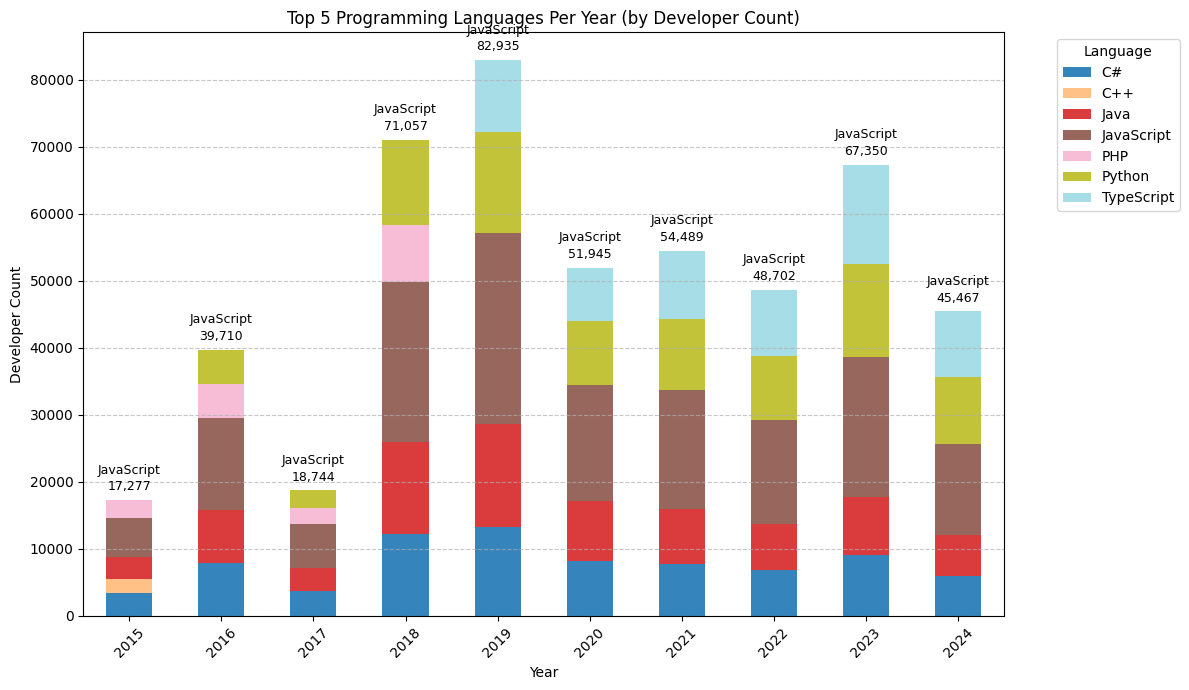

In [7]:
top_langs_pd = top_count_lang_per_year.toPandas().sort_values(["year", "repo_count"], ascending=[True, False])

pivot_df = top_langs_pd.pivot(index="year", columns="language", values="repo_count").fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))
pivot_df.plot(kind="bar", stacked=True, colormap="tab20", alpha=0.9, ax=ax)

top1_langs = top_langs_pd.groupby("year").first().reset_index()  

for i, year in enumerate(pivot_df.index):
    count = int(pivot_df.loc[year].sum())
    top_lang = top1_langs[top1_langs["year"] == year]["language"].values[0]
    
    ax.text(i, count + 1000, f"{count:,}", ha="center", va="bottom", fontsize=9, color="black")
    ax.text(i, count + 3500, f"{top_lang}", ha="center", va="bottom", fontsize=9, color="black")


ax.set_title("Top 5 Programming Languages Per Year (by Developer Count)")
ax.set_xlabel("Year")
ax.set_ylabel("Developer Count")
ax.set_xticklabels(pivot_df.index, rotation=45)
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
ax.legend(title="Language", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


### Create View of Average Salary per Language and Year  
Compute average yearly salary for each language, filtering out entries with zero salary and languages with low response counts.  


In [8]:
spark.sql("""
   CREATE OR REPLACE TEMP VIEW language_yearly_salary AS
    SELECT
        Year AS year,
        Language AS language,
        COUNT(*) AS count,
        AVG(ConvertedCompYearly) AS avg_salary
    FROM language_salary_raw
    WHERE ConvertedCompYearly > 0  
    GROUP BY Year, Language
    HAVING COUNT(*) > 50           

""")

DataFrame[]

### Identify Top Paying Language per Year  
Use a window function to rank languages by average salary per year and select the highest-paying language annually.  


In [9]:
top_salary_lang_per_year = spark.sql("""
    SELECT year, language, avg_salary
    FROM (
        SELECT
            year,
            language,
            avg_salary,
            ROW_NUMBER() OVER (PARTITION BY year ORDER BY avg_salary DESC) AS rank
        FROM language_yearly_salary
    )
    WHERE rank = 1
    ORDER BY year
""")


top_salary_pd = top_salary_lang_per_year.toPandas()
top_salary_pd = top_salary_pd.dropna()
top_salary_pd["year"] = top_salary_pd["year"].astype(int)
top_salary_pd = top_salary_pd.sort_values(by="year")


### Visualize Highest-Paying Language Per Year  
Generate a line chart to show which programming language had the highest average salary each year according to survey data.  


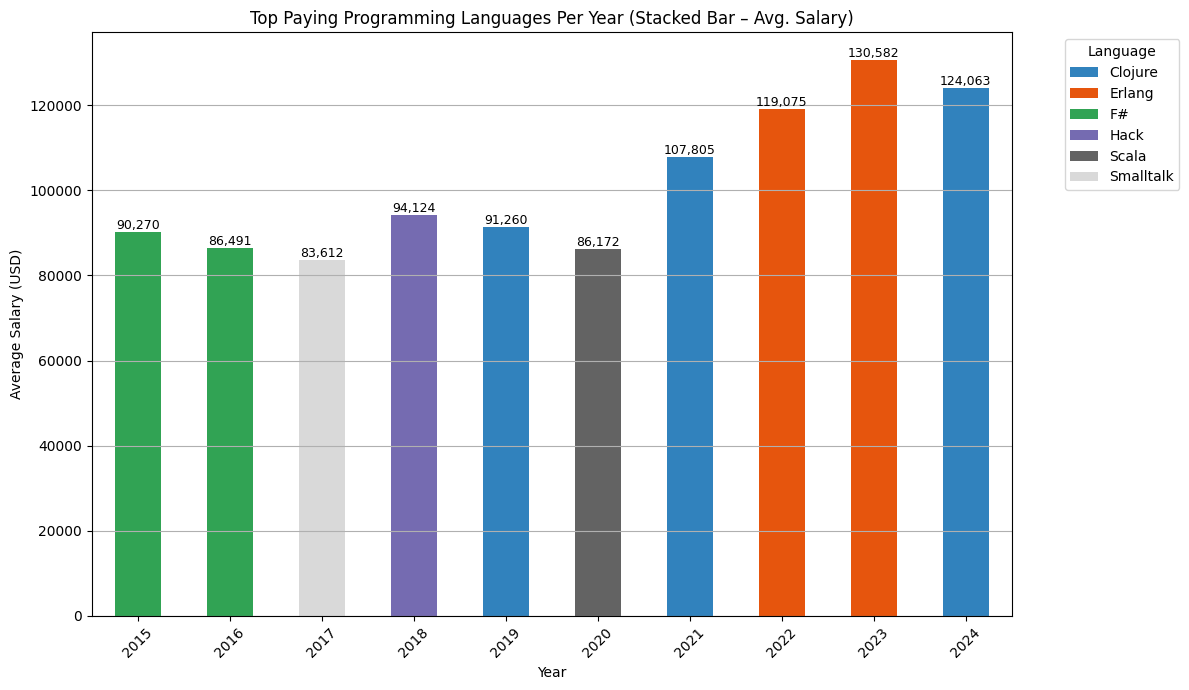

In [10]:
pivot_salary_df = top_salary_pd.pivot(index="year", columns="language", values="avg_salary").fillna(0)

ax = pivot_salary_df.plot(kind="bar", stacked=True, figsize=(12, 7), colormap="tab20c")

plt.title("Top Paying Programming Languages Per Year (Stacked Bar – Avg. Salary)")
plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.legend(title="Language", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2, p.get_y() + height),
                    ha='center', va='bottom', fontsize=9)

plt.show()

### Prepare Country-Level Salary Data
Select valid rows with Country and salary, excluding nulls and non-positive sal

In [11]:
df_country_salary = df.select("Country", "ConvertedCompYearly") \
    .dropna(subset=["Country", "ConvertedCompYearly"]) \
    .filter(col("ConvertedCompYearly") > 0)

### Compute Average Salary by Country  
Group responses by country and calculate average salary and response count, keeping only countries with at least 100 entries.  


In [12]:
df_avg_salary_country = df_country_salary.groupBy("Country") \
    .agg(
        F.avg("ConvertedCompYearly").alias("avg_salary"),
        F.count("*").alias("count")
    ) \
    .filter("count >= 100") \
    .orderBy(F.col("avg_salary").desc())


### Visualize Top Paying Countries  
Convert salary data to Pandas, extract top 20 countries by average salary, and plot them as a horizontal bar chart.  


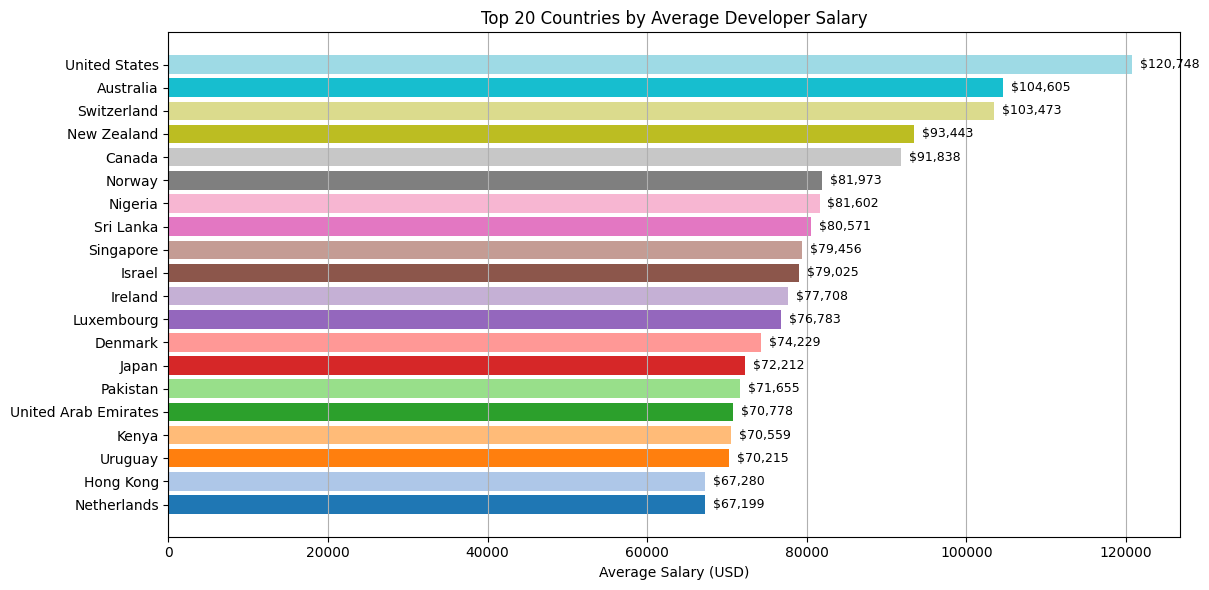

In [13]:
df_avg_salary_pd = df_avg_salary_country.toPandas()
df_avg_salary_pd["avg_salary"] = df_avg_salary_pd["avg_salary"].round(2)

top_n = 20
top_countries = df_avg_salary_pd.head(top_n)

plt.figure(figsize=(12, 6))
colors = plt.cm.tab20.colors[:top_n]

bars = plt.barh(
    top_countries["Country"][::-1],
    top_countries["avg_salary"][::-1],
    color=colors
)

plt.xlabel("Average Salary (USD)")
plt.title(f"Top {top_n} Countries by Average Developer Salary")
plt.tight_layout()
plt.grid(axis="x")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1000,  # Abstand rechts neben Balken
             bar.get_y() + bar.get_height() / 2,
             f"${int(width):,}",
             va='center', fontsize=9)

plt.show()


### Calculate Average Salary Per Language  
Group by programming language, compute average salary and count, filter out small samples, and sort by salary descending.  


In [14]:
df_avg_salary_per_lang = df_exploded.groupBy("Language") \
    .agg(
        F.avg("ConvertedCompYearly").alias("avg_salary"),
        F.count("*").alias("count")
    ) \
    .filter("count >= 50") \
    .orderBy(col("avg_salary").desc())

### Plot Top Programming Languages by Average Salary  
Convert results to Pandas, extract top 20 languages by salary, and visualize with a horizontal bar chart including salary labels.  


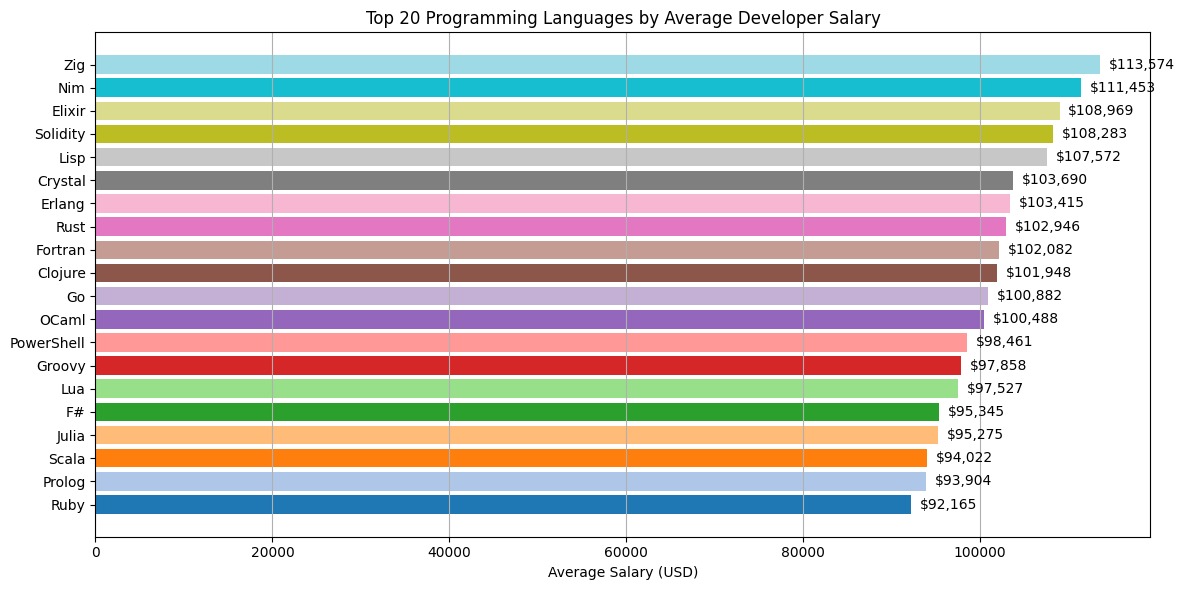

In [15]:
df_avg_salary_pd = df_avg_salary_per_lang.toPandas()
df_avg_salary_pd["avg_salary"] = df_avg_salary_pd["avg_salary"].round(2)

top_n = 20
top_languages = df_avg_salary_pd.head(top_n)

plt.figure(figsize=(12, 6))
colors = plt.cm.tab20.colors[:top_n]  

bars = plt.barh(
    top_languages["Language"][::-1], 
    top_languages["avg_salary"][::-1],
    color=colors
)

for bar, value in zip(bars, top_languages["avg_salary"][::-1]):
    plt.text(
        bar.get_width() + 1000,  
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va='center'
    )

plt.xlabel("Average Salary (USD)")
plt.title(f"Top {top_n} Programming Languages by Average Developer Salary")
plt.tight_layout()
plt.grid(axis="x")
plt.show()


### Combine Top and Common Programming Languages  
Select top 20 languages by average salary and append popular languages, then remove duplicates and sort by salary.  


In [16]:
common_languages = {
    "Python", "JavaScript", "Java", "C#", "C++", "C", "TypeScript", "Go", "PHP", "Rust"
}

top_n = 20
top_languages = df_avg_salary_pd.sort_values(by="avg_salary", ascending=False).head(top_n)
common_lang_rows = df_avg_salary_pd[df_avg_salary_pd["Language"].isin(common_languages)]
combined = pd.concat([top_languages, common_lang_rows]).drop_duplicates(subset=["Language"])
combined = combined.sort_values(by="avg_salary", ascending=False)

### Batch Plot Programming Languages by Salary  
Split language-salary data into chunks of N entries, highlight common languages in orange, and generate one horizontal bar chart per batch.  


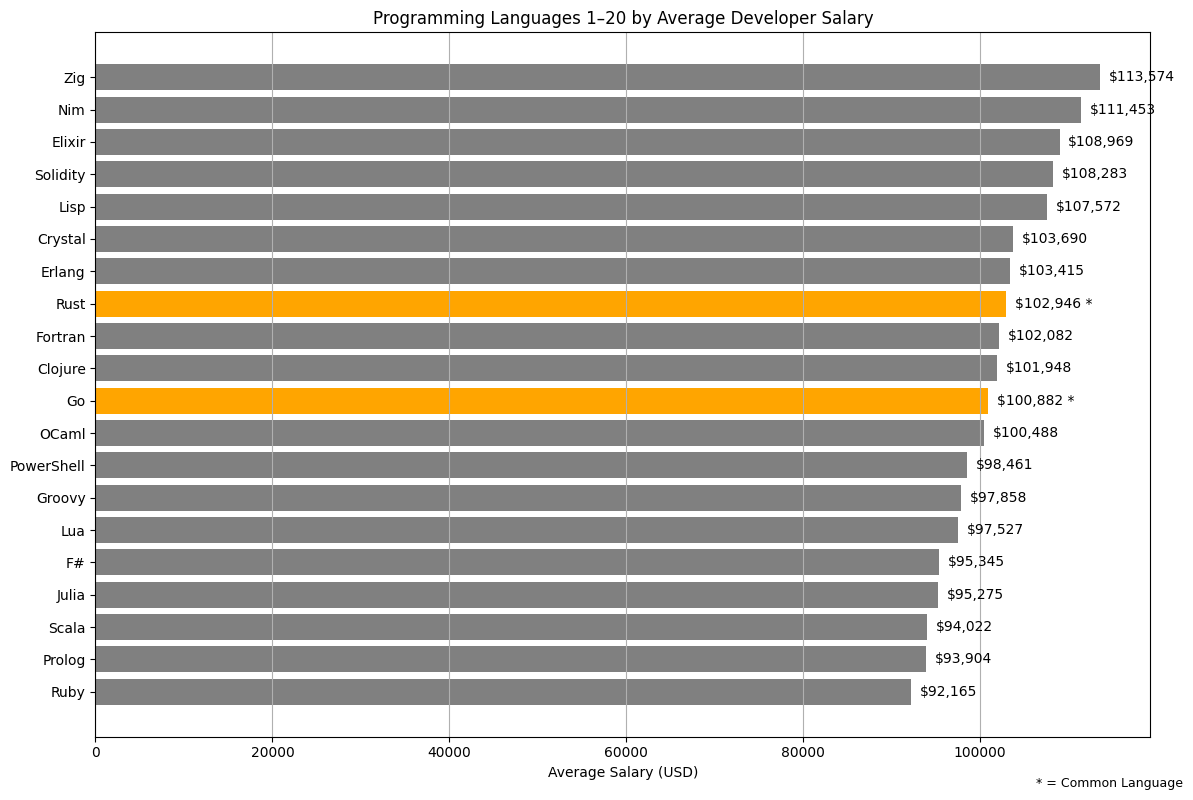

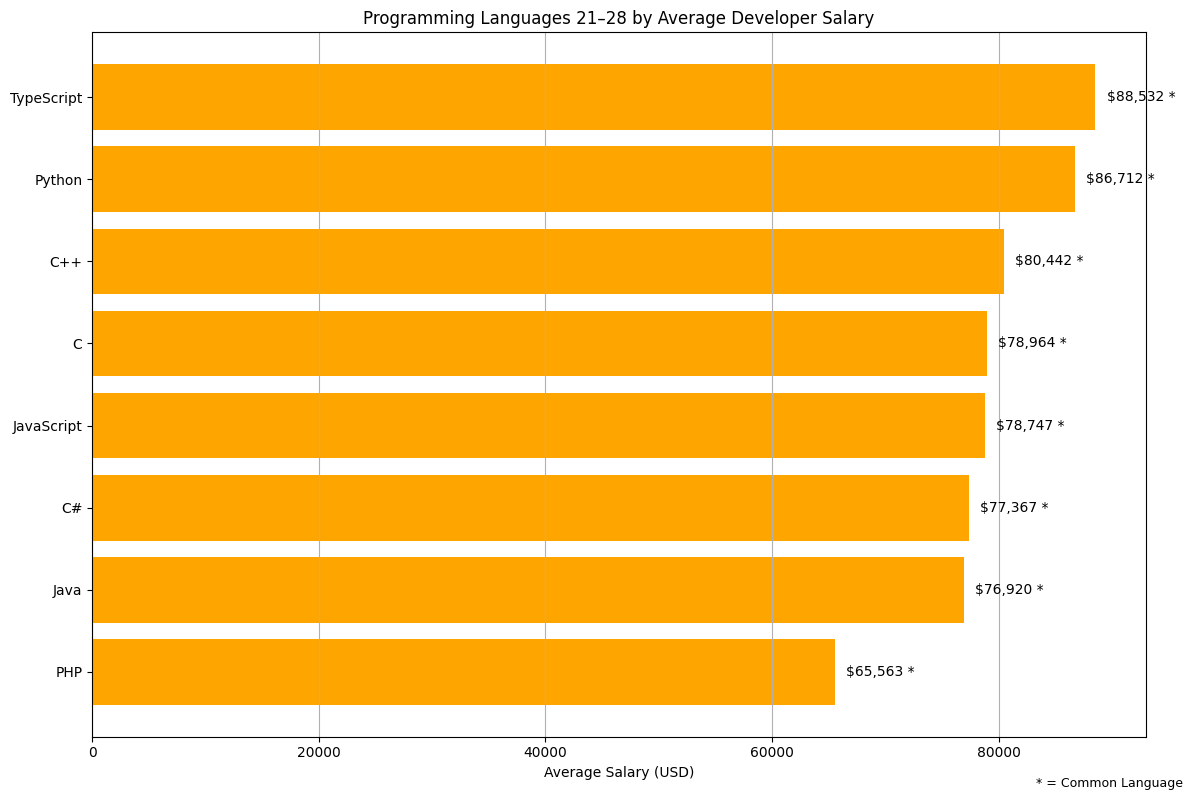

In [17]:
batch_size = 20
combined_sorted = combined.sort_values(by="avg_salary", ascending=False).reset_index(drop=True)

for i in range(0, len(combined_sorted), batch_size):
    batch = combined_sorted.iloc[i:i+batch_size]
    colors = ["orange" if lang in common_languages else "gray" for lang in batch["Language"]][::-1]
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(
        batch["Language"][::-1],
        batch["avg_salary"][::-1],
        color=colors
    )

    for bar, lang, value in zip(bars, batch["Language"][::-1], batch["avg_salary"][::-1]):
        label = f"${value:,.0f}"
        if lang in common_languages:
            label += " *"
        plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, label, va="center")

    plt.xlabel("Average Salary (USD)")
    plt.title(f"Programming Languages {i+1}–{i+len(batch)} by Average Developer Salary")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.figtext(0.99, 0.01, "* = Common Language", ha="right", fontsize=9)
    plt.show()


### Top 10 Experience Levels by Average Salary  
Compute the average salary per years of coding experience using PySpark.  
Filter out invalid or low-frequency entries, and display the top 10 experience levels sorted by average salary (only levels with ≥ 50 responses are considered).


In [18]:
df_exp_salary = df.select("YearsCode", "ConvertedCompYearly") \
    .dropna(subset=["YearsCode", "ConvertedCompYearly"]) \
    .filter(col("ConvertedCompYearly") > 0)

df_avg_salary_by_exp = df_exp_salary.groupBy("YearsCode") \
    .agg(
        F.avg("ConvertedCompYearly").alias("avg_salary"),
        F.count("*").alias("count")
    ) \
    .filter("count >= 50") \
    .orderBy(col("avg_salary").desc())

df_top_exp_pd = df_avg_salary_by_exp.toPandas()
df_top_exp_pd["avg_salary"] = df_top_exp_pd["avg_salary"].round(2)

print(" Top 10 experience levels by average salary:")
print(df_top_exp_pd.head(10))


 Top 10 experience levels by average salary:
  YearsCode  avg_salary  count
0      28.0   118203.63   1717
1      27.0   113897.92   1586
2      30.0   113802.77   4693
3      26.0   113627.98   1704
4      25.0   112049.06   5832
5      24.0   111133.89   2295
6      23.0   110900.93   2576
7      29.0   110595.96    759
8      22.0   107766.02   3995
9      21.0   104768.89   2224


### Line Plot: Average Developer Salary by Years of Experience  
Convert and clean experience-salary data, sort by years, and visualize the average salary trend across different levels of coding experience using a line chart.


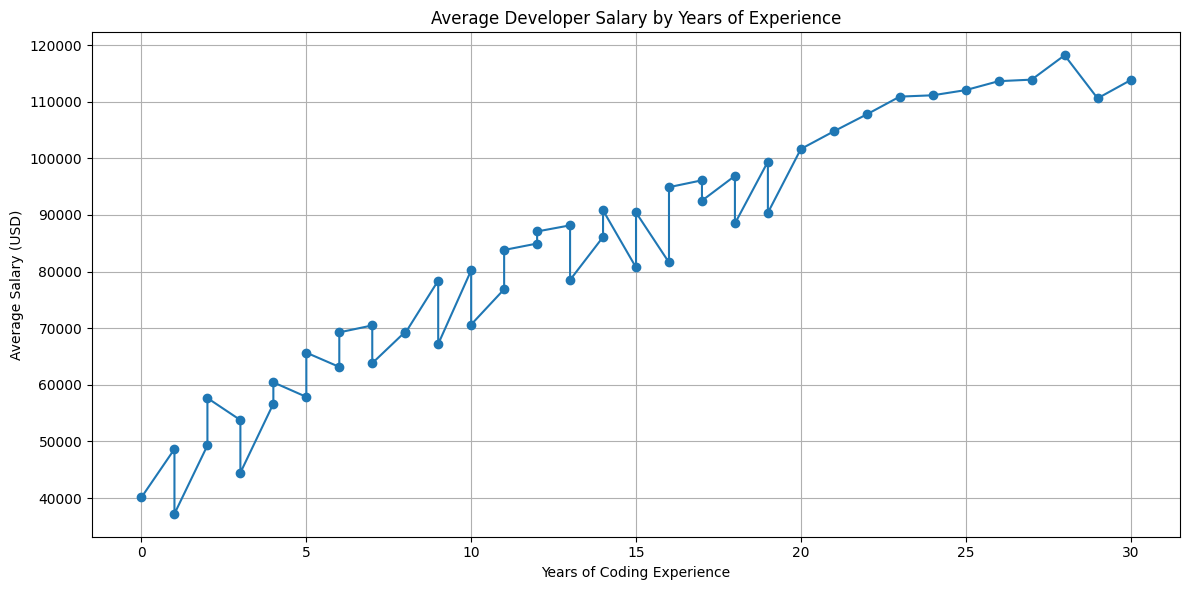

In [19]:
df_avg_salary_exp_pd = df_avg_salary_by_exp.toPandas()

df_avg_salary_exp_pd = df_avg_salary_exp_pd[
    pd.to_numeric(df_avg_salary_exp_pd["YearsCode"], errors="coerce").notna()
]
df_avg_salary_exp_pd["YearsCode"] = df_avg_salary_exp_pd["YearsCode"].astype(float).astype(int)

df_avg_salary_exp_pd = df_avg_salary_exp_pd.sort_values(by="YearsCode")
df_avg_salary_exp_pd["avg_salary"] = df_avg_salary_exp_pd["avg_salary"].round(2)

plt.figure(figsize=(12, 6))
plt.plot(
    df_avg_salary_exp_pd["YearsCode"],
    df_avg_salary_exp_pd["avg_salary"],
    marker="o"
)

plt.title("Average Developer Salary by Years of Experience")
plt.xlabel("Years of Coding Experience")
plt.ylabel("Average Salary (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Create Combined View of Popularity and Salary for Correlation 
Build a temporary view that links each language’s popularity (count) with its average salary per year for correlation analysis.  


In [20]:
spark.sql("""
   CREATE OR REPLACE TEMP VIEW language_popularity_salary AS
    SELECT
        Year AS year,
        Language AS language,
        COUNT(*) AS popularity,
        AVG(ConvertedCompYearly) AS avg_salary
    FROM language_salary_raw
    WHERE ConvertedCompYearly > 0
    GROUP BY Year, Language
    HAVING COUNT(*) > 50
""")

DataFrame[]

In [21]:
years = list(range(2015, 2025)) 

for y in years:
    df_debug = spark.sql(f"""
        SELECT year, language, popularity, avg_salary
        FROM language_popularity_salary
        WHERE year = {y}
    """)
    
    df_debug_pd = df_debug.toPandas()
    
    if not df_debug_pd.empty:
        top5 = df_debug_pd.sort_values(by="popularity", ascending=False).head(5)
        print(f"\n Top 5 Languages for Year {y} sorted by popularity:")
        print(top5.to_string(index=False))
    else:
        print(f"\n No Data for Year: {y}")



 Top 5 Languages for Year 2015 sorted by popularity:
year   language  popularity   avg_salary
2015 JavaScript        5780 56103.806228
2015         C#        3371 60602.195194
2015       Java        3327 54598.737601
2015        PHP        2660 45105.263158
2015        C++        2139 62519.869098

 Top 5 Languages for Year 2016 sorted by popularity:
year   language  popularity   avg_salary
2016 JavaScript       13758 62430.585841
2016         C#        7904 66344.888664
2016       Java        7832 64682.073544
2016        PHP        5169 52794.544399
2016     Python        5047 71200.713295

 Top 5 Languages for Year 2017 sorted by popularity:
year   language  popularity   avg_salary
2017 JavaScript        6553 64552.824508
2017         C#        3764 66025.193624
2017       Java        3442 64272.139831
2017     Python        2680 69621.890784
2017        PHP        2305 54810.748677

 Top 5 Languages for Year 2018 sorted by popularity:
year   language  popularity   avg_salary
2018 

### Calculate Pearson Correlation (Popularity vs. Salary)  
For each year, compute the Pearson correlation between language popularity and average salary using Spark’s correlation API.  


In [22]:
correlations = []

years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

for y in years:
    df_year = spark.sql(f"""
        SELECT popularity, avg_salary
        FROM language_popularity_salary
        WHERE year = {y}
    """)
    
    if df_year.count() > 2:
        assembler = VectorAssembler(inputCols=["popularity", "avg_salary"], outputCol="features")
        df_vector = assembler.transform(df_year).select("features")
        corr_matrix = Correlation.corr(df_vector, "features", "pearson").collect()[0][0]
        corr_value = corr_matrix[0, 1]
        correlations.append((y, round(float(corr_value), 3)))
print("Year | Pearson-Correlation (Popularity vs. Salary)")
for year, corr in correlations:
    print(f"{year}  |  {corr}")

Year | Pearson-Correlation (Popularity vs. Salary)
2015  |  -0.638
2016  |  -0.622
2017  |  -0.491
2018  |  -0.365
2019  |  -0.39
2020  |  -0.298
2021  |  -0.251
2022  |  -0.277
2023  |  -0.116
2024  |  -0.149


### Visualize Pearson Correlation Over Time  
Plot a line chart to show how the correlation between language popularity and salary has changed across the years.  


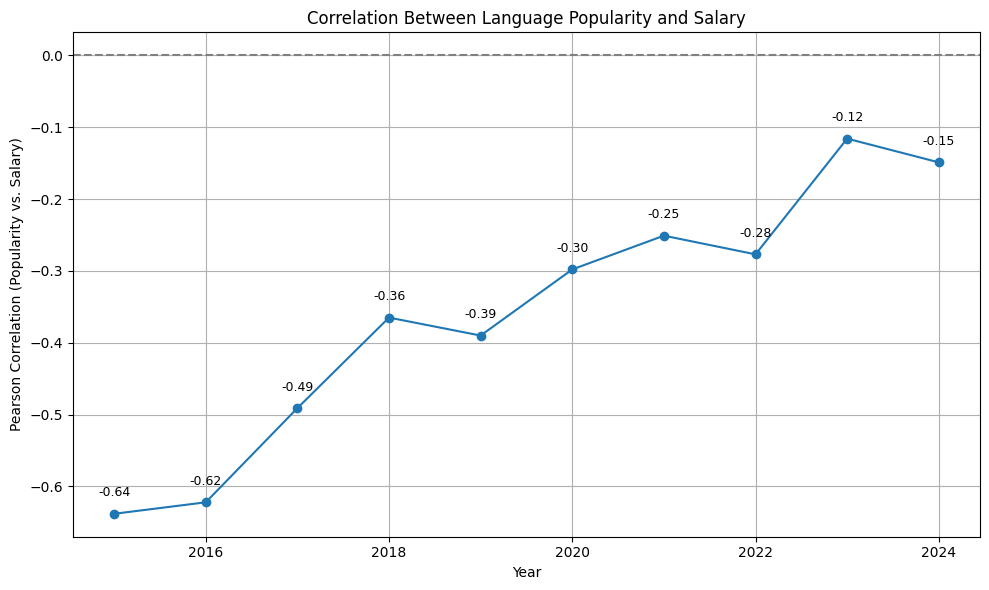

In [23]:

df_corr = pd.DataFrame(correlations, columns=["year", "correlation"])
plt.figure(figsize=(10, 6))
plt.plot(df_corr["year"], df_corr["correlation"], marker="o")
plt.title("Correlation Between Language Popularity and Salary")
plt.xlabel("Year")
plt.ylabel("Pearson Correlation (Popularity vs. Salary)")
plt.axhline(0, color="gray", linestyle="--")
plt.grid(True)
plt.tight_layout()
for x, y in zip(df_corr["year"], df_corr["correlation"]):
    plt.text(x, y + 0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=9)

plt.show()


### Calculate Spearman Correlation (Popularity vs. Salary)  
For each year, compute the Spearman rank correlation to capture monotonic relationships between language popularity and salary.  


In [24]:
spearman_correlations = []

for y in years:
    df_year = spark.sql(f"""
        SELECT popularity, avg_salary
        FROM language_popularity_salary
        WHERE year = {y}
    """)
    
    if df_year.count() > 2:
        assembler = VectorAssembler(inputCols=["popularity", "avg_salary"], outputCol="features")
        df_vector = assembler.transform(df_year).select("features")
        spearman_corr_matrix = Correlation.corr(df_vector, "features", method="spearman").collect()[0][0]
        spearman_corr_value = spearman_corr_matrix[0, 1]
        spearman_correlations.append((y, round(float(spearman_corr_value), 3)))

print("Year | Spearman-Correlation (Popularity vs. Salary)")
for year, corr in spearman_correlations:
    print(f"{year}  |  {corr}")

Year | Spearman-Correlation (Popularity vs. Salary)
2015  |  -0.842
2016  |  -0.748
2017  |  -0.715
2018  |  -0.513
2019  |  -0.403
2020  |  -0.258
2021  |  -0.255
2022  |  -0.38
2023  |  -0.084
2024  |  -0.136


### Visualize Spearman Correlation Over Time  
Generate a line plot to display how the Spearman correlation between language popularity and salary evolved year by year.  


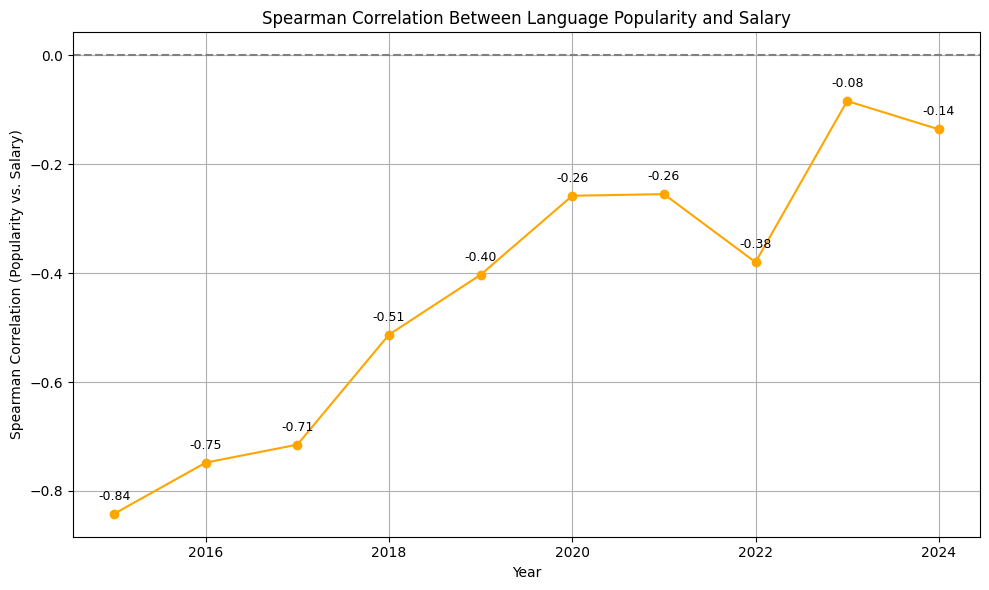

In [25]:
df_spearman_corr = pd.DataFrame(spearman_correlations, columns=["year", "correlation"])

plt.figure(figsize=(10, 6))
plt.plot(df_spearman_corr["year"], df_spearman_corr["correlation"], marker="o", color="orange")
plt.title("Spearman Correlation Between Language Popularity and Salary")
plt.xlabel("Year")
plt.ylabel("Spearman Correlation (Popularity vs. Salary)")
plt.axhline(0, color="gray", linestyle="--")
plt.grid(True)
plt.tight_layout()
for x, y in zip(df_spearman_corr["year"], df_spearman_corr["correlation"]):
    plt.text(x, y + 0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=9)

plt.show()


### Compare Pearson and Spearman Correlation  
Plot both Pearson and Spearman correlations over time to contrast linear and rank-based relationships between popularity and salary.  


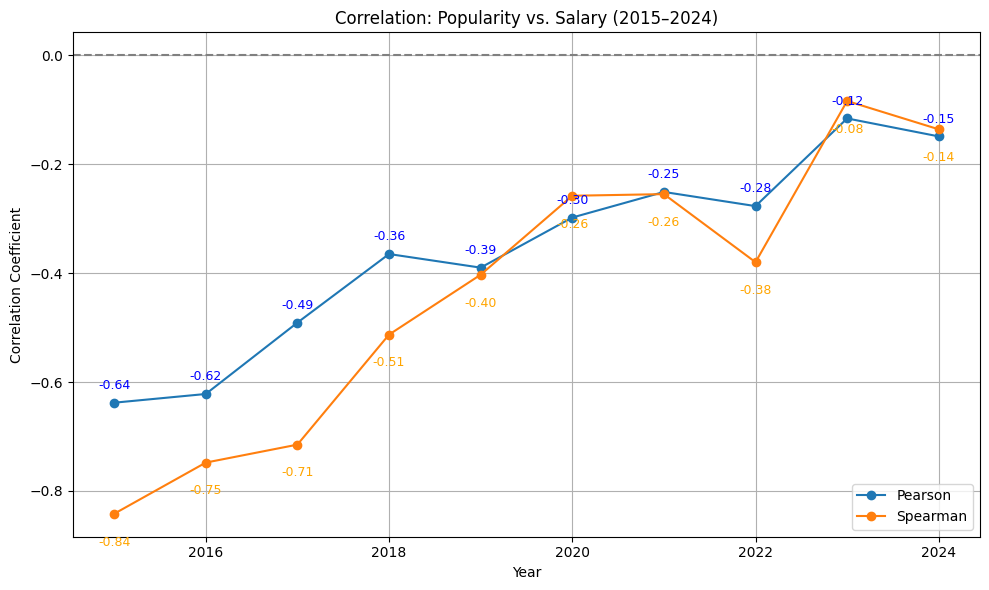

In [26]:
pearson_data = [
    (2015, -0.638), (2016, -0.622), (2017, -0.491), (2018, -0.365),
    (2019, -0.390), (2020, -0.298), (2021, -0.251), (2022, -0.277),
    (2023, -0.116), (2024, -0.149)
]

spearman_data = [
    (2015, -0.842), (2016, -0.748), (2017, -0.715), (2018, -0.513),
    (2019, -0.403), (2020, -0.258), (2021, -0.255), (2022, -0.380),
    (2023, -0.084), (2024, -0.136)
]

df_pearson = pd.DataFrame(pearson_data, columns=["year", "pearson"])
df_spearman = pd.DataFrame(spearman_data, columns=["year", "spearman"])

df_combined = pd.merge(df_pearson, df_spearman, on="year")

plt.figure(figsize=(10, 6))
plt.plot(df_combined["year"], df_combined["pearson"], label="Pearson", marker="o")
plt.plot(df_combined["year"], df_combined["spearman"], label="Spearman", marker="o")

plt.title("Correlation: Popularity vs. Salary (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Correlation Coefficient")
plt.axhline(0, color="gray", linestyle="--")
plt.grid(True)
plt.legend()
plt.tight_layout()
for x, y in zip(df_combined["year"], df_combined["pearson"]):
    plt.text(x, y + 0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=9, color="blue")

for x, y in zip(df_combined["year"], df_combined["spearman"]):
    plt.text(x, y - 0.04, f"{y:.2f}", ha='center', va='top', fontsize=9, color="orange")

plt.show()


## Future-Oriented Tech Career Potential Analysis

This analysis identifies the most promising combinations of programming languages, experience levels, and countries by integrating multiple weighted factors: current salary levels, popularity, long-term trend momentum, experience-based compensation, and regional earning potential. Unlike a snapshot of today's job market, this model estimates future attractiveness by combining both current and forward-looking indicators. It highlights where skills, demand, and location converge to form strong long-term opportunities.


###  Language–Experience Salary View
Creates a temp view with average salary and popularity per language and experience level, excluding entries with low sample size.

In [27]:
spark.sql("""
    CREATE OR REPLACE TEMP VIEW lang_salary_exp_view AS
    SELECT
        Language AS language,
        CAST(YearsCode AS INT) AS experience_years,
        AVG(ConvertedCompYearly) AS avg_salary,
        COUNT(*) AS popularity
    FROM language_salary_raw
    WHERE ConvertedCompYearly > 0 AND YearsCode IS NOT NULL
    GROUP BY Language, CAST(YearsCode AS INT)
    HAVING COUNT(*) > 50
""")


DataFrame[]

### Load Language–Experience Aggregated Salary & Popularity

In [28]:
lang_exp_pop_df = spark.sql("SELECT * FROM lang_salary_exp_view").toPandas()
lang_exp_pop_df["experience_years"] = lang_exp_pop_df["experience_years"].astype(int)

avg_salary_map = lang_exp_pop_df.set_index(["language", "experience_years"])["avg_salary"].to_dict()
popularity_map = lang_exp_pop_df.set_index(["language", "experience_years"])["popularity"].to_dict()


### Load Country-Level Average Salaries

In [29]:
df_country_salary = df_avg_salary_country.toPandas()
df_country_salary["avg_salary"] = df_country_salary["avg_salary"].round(2)


### Load Experience-Based Average Salaries 

In [30]:
df_exp_salary = df_avg_salary_exp_pd.copy()
df_exp_salary = df_exp_salary[df_exp_salary["YearsCode"].notna()]
df_exp_salary["YearsCode"] = df_exp_salary["YearsCode"].astype(int)
exp_salary_map = df_exp_salary.set_index("YearsCode")["avg_salary"].to_dict()


### Load & Calculate Trend Scores (CSV + GitHub Repo Growth)

In [31]:
trend_csv = pd.read_csv("./RestAPIData/trend_score_repo_growth_2015_2024.csv")
trend_csv = trend_csv.dropna(subset=["trend_score"])[["language", "trend_score"]]
trend_csv["trend_score"] = trend_csv["trend_score"].astype(float)

df_counts = spark.sql("SELECT * FROM language_yearly_counts WHERE year BETWEEN 2015 AND 2024").toPandas()
df_counts = df_counts.dropna()
df_counts["year"] = df_counts["year"].astype(int)
df_counts["repo_count"] = df_counts["repo_count"].astype(int)

trend_raw = df_counts.sort_values(["language", "year"]) \
    .groupby("language")["repo_count"].apply(lambda x: x.diff().mean()).reset_index(name="trend_raw")

scaler = MinMaxScaler()
trend_raw["trend_score"] = scaler.fit_transform(trend_raw[["trend_raw"]]) * 10
trend_raw["trend_score"] = trend_raw["trend_score"].round(1)


### Combine Trend Sources into Unified Score

In [32]:
combined_trend = pd.concat([trend_csv, trend_raw[["language", "trend_score"]]])
combined_trend = combined_trend.groupby("language", as_index=False)["trend_score"].mean().round(1)
combined_trend.to_csv("./RestAPIData/combined_trend_score_2015_2024.csv", index=False)


### Generate All Language–Experience–Country Combinations

In [33]:
languages = lang_exp_pop_df["language"].unique()
experience_years = sorted(exp_salary_map.keys())
countries = df_country_salary["Country"].unique()
combinations = list(product(languages, experience_years, countries))


### Build Feature Rows for Each Combination

In [34]:
rows = []

for lang, exp, country in combinations:
    region_row = df_country_salary[df_country_salary["Country"] == country]
    trend_row = combined_trend[combined_trend["language"] == lang]

    avg_salary = avg_salary_map.get((lang, exp))
    popularity = popularity_map.get((lang, exp))
    exp_salary = exp_salary_map.get(exp)

    if avg_salary and popularity and not region_row.empty and exp_salary:
        rows.append({
            "language": lang,
            "experience_years": exp,
            "country": country,
            "avg_salary": avg_salary,
            "popularity": popularity,
            "exp_salary": exp_salary,
            "region_salary": region_row["avg_salary"].values[0],
            "trend_score": trend_row["trend_score"].values[0] if not trend_row.empty else 0
        })

df_combined = pd.DataFrame(rows)


### Normalize Features & Calculate Future Score

In [35]:
scaler = MinMaxScaler()
df_combined[[
    "salary_norm", "popularity_norm", "trend_norm", "exp_salary_norm", "region_norm"
]] = scaler.fit_transform(df_combined[[
    "avg_salary", "popularity", "trend_score", "exp_salary", "region_salary"
]])

df_combined["future_score"] = (
    0.35 * df_combined["salary_norm"] +
    0.20 * df_combined["popularity_norm"] +
    0.15 * df_combined["trend_norm"] +
    0.20 * df_combined["exp_salary_norm"] +
    0.10 * df_combined["region_norm"]
)

df_result = df_combined.sort_values(by="future_score", ascending=False)


### Output: Top Results

In [36]:
print("\nTop Language–Experience–Country Combinations for the Future:")
print(df_result[[
    "language", "experience_years", "country",
    "avg_salary", "exp_salary", "region_salary", "future_score"
]].head(15).to_string(index=False))



Top Language–Experience–Country Combinations for the Future:
  language  experience_years       country    avg_salary  exp_salary  region_salary  future_score
    Python                28 United States 123679.789889   118203.63      120748.62      0.751759
    Python                30 United States 121351.976744   113802.77      120748.62      0.750912
    Python                25 United States 117644.362832   112049.06      120748.62      0.740674
TypeScript                28 United States 126072.317568   118203.63      120748.62      0.738331
    Python                28     Australia 123679.789889   118203.63      104605.42      0.734789
    Python                30     Australia 121351.976744   113802.77      104605.42      0.733942
    Python                28   Switzerland 123679.789889   118203.63      103473.65      0.733600
    Python                30   Switzerland 121351.976744   113802.77      103473.65      0.732753
    Python                27 United States 119993.593301

In [37]:
top_1y = df_result[df_result["experience_years"] == 1].sort_values("future_score", ascending=False).head(1)
top_5y = df_result[df_result["experience_years"] == 5].sort_values("future_score", ascending=False).head(1)
top_10y = df_result[df_result["experience_years"] == 10].sort_values("future_score", ascending=False).head(1)
top_all = df_result.head(1)  # bereits sortiert nach future_score

summary = pd.concat([top_1y, top_5y, top_10y, top_all]).drop_duplicates()

print("\n Top Language–Experience–Country Combinations by Level:\n")
print(summary[[
    "language", "experience_years", "country",
    "avg_salary", "exp_salary", "region_salary", "future_score"
]].to_string(index=False))



 Top Language–Experience–Country Combinations by Level:

language  experience_years       country    avg_salary  exp_salary  region_salary  future_score
  Python                 1 United States  52452.161281    37222.96      120748.62      0.370398
  Python                 5 United States  70246.036798    65683.46      120748.62      0.500582
  Python                10 United States  86451.392070    70644.65      120748.62      0.628406
  Python                28 United States 123679.789889   118203.63      120748.62      0.751759


In [38]:
spark.stop()
logger.info("Spark session stopped.")

2025-06-23 11:33:08,966 - INFO - Spark session stopped.
